# 🔤 Roman Urdu → Urdu Transliteration — ByT5-small **Version 2.0**
### Production-Ready NLP Training Pipeline

| Setting | V1 | **V2** |
|---|---|---|
| Dataset size | 20,000 | **40,000** |
| Split ratio | 16k / 2k / 2k | **32k / 4k / 4k (80/10/10)** |
| MAX_LENGTH | 64 | **256** |
| Batch size | 16 | **4 (+ grad_accum=8 → eff. 32)** |
| Epochs | 6 | **3** |
| Checkpoints | Google Drive | **Local /content/local_checkpoints** |
| Final model | Google Drive `final_model` | **Google Drive `final_model_v2`** |

> **Storage strategy:** intermediate checkpoints → Colab local storage (free, fast, ephemeral).  
> Only the **one final model** is written to Drive, protecting your 15 GB quota.


## 📦 Phase 1 — Environment Setup

### Cell 1 · Install Dependencies

In [ ]:
# CELL 1 — Install Dependencies
# ─────────────────────────────────────────────────────────────────────────────
# No version changes from V1; pins kept for reproducibility.
# ─────────────────────────────────────────────────────────────────────────────
!python -m pip install --upgrade pip --quiet
!pip install \
    "transformers>=4.41.2" \
    "datasets>=2.20.0" \
    "accelerate>=0.31.0" \
    evaluate sacrebleu jiwer sentencepiece --quiet

print("✅ All packages installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 17.8 MB/s eta 0:00:00
✅ All packages installed.


### Cell 2 · Version Verification

In [ ]:
# CELL 2 — Version Lock & Environment Verification
# ─────────────────────────────────────────────────────────────────────────────
import sys
import importlib.metadata
import torch, transformers, datasets, accelerate, evaluate
import sacrebleu, jiwer, sentencepiece
import numpy as np
import pandas as pd

def get_version(pkg):
    try:
        return importlib.metadata.version(pkg)
    except importlib.metadata.PackageNotFoundError:
        return "unknown"

print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")
print(f"Transformers: {get_version('transformers')}")
print(f"Datasets    : {get_version('datasets')}")
print(f"Accelerate  : {get_version('accelerate')}")
print(f"Evaluate    : {get_version('evaluate')}")
print(f"SacreBLEU   : {get_version('sacrebleu')}")
print(f"JiWER       : {get_version('jiwer')}")
print(f"SentencePiece:{get_version('sentencepiece')}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")


Python      : 3.12.13
PyTorch     : 2.11.0+cu128
Transformers: 5.9.0
Datasets    : 4.0.0
Accelerate  : 1.13.0
Evaluate    : 0.4.6
SacreBLEU   : 2.6.0
JiWER       : 4.0.0
SentencePiece:0.2.1
NumPy       : 2.0.2
Pandas      : 2.2.2


### Cell 3 · GPU Check

In [ ]:
# CELL 3 — GPU Availability & Memory Check
# ─────────────────────────────────────────────────────────────────────────────
import torch

if torch.cuda.is_available():
    print(f"GPU Available : True")
    print(f"Device Name   : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version  : {torch.version.cuda}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"Total VRAM    : {total_mem:.1f} GB")
    print("\n--- GPU Memory Summary ---")
    print(torch.cuda.memory_summary(device=0, abbreviated=True))
else:
    raise SystemError(
        "CRITICAL: GPU not detected.\n"
        "Go to Runtime → Change runtime type → Hardware accelerator → T4 GPU."
    )


GPU Available : True
Device Name   : Tesla T4
CUDA Version  : 12.8
Total VRAM    : 14.6 GB

--- GPU Memory Summary ---
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory     

### Cell 4 · Reproducibility Seeds

In [ ]:
# CELL 4 — Reproducibility Setup  (seed = 42, same as V1)
# ─────────────────────────────────────────────────────────────────────────────
import random, os
import numpy as np
import torch
from transformers import set_seed

def set_deterministic_environment(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    set_seed(seed)
    print(f"✅ All random seeds locked to: {seed}")

set_deterministic_environment(42)


✅ All random seeds locked to: 42


### Cell 5 · Safe Imports

In [ ]:
# CELL 5 — Safe Import Block
# ─────────────────────────────────────────────────────────────────────────────
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)
import evaluate
import jiwer
import sacrebleu

print("✅ All dependencies successfully imported.")


✅ All dependencies successfully imported.


## 📊 Phase 2 — Dataset Preparation (V2: 40k samples, 80/10/10 split)

### Cell 6 · Load, Shuffle & Sample 40,000 rows
> **V2 change:** Dataset is doubled to **40,000 samples** (up from 20,000) and split  
> strictly 80 / 10 / 10 → **32,000 train / 4,000 val / 4,000 test**  
> using the native Hugging Face `datasets` API — no sklearn dependency needed.


In [ ]:
# CELL 6 — Dataset Loading, Shuffle & 40k Sample
# ─────────────────────────────────────────────────────────────────────────────
# V2 CHANGE: 40,000 samples (was 20,000 in V1)
# ─────────────────────────────────────────────────────────────────────────────
import unicodedata, re
from datasets import load_dataset, Dataset, DatasetDict

print("--- 1. LOADING DATASET ---")
raw_train = load_dataset("Mavkif/Roman-Urdu-Parl-split", split="train")
print(f"Full train split size: {len(raw_train):,}")

# Shuffle with seed=42 then take exactly 40,000 rows
raw_train = raw_train.shuffle(seed=42).select(range(40_000))
print(f"Sampled size          : {len(raw_train):,}")

# Identify source / target columns dynamically (safe against column name changes)
sample_row = raw_train[0]
roman_col = next(c for c in sample_row if 'roman' in c.lower() or c.lower() in ('en', 'src'))
urdu_col  = next(c for c in sample_row if 'ur' in c.lower()  or c.lower() in ('tgt', 'urdu'))
print(f"Source column: '{roman_col}'  |  Target column: '{urdu_col}'")


--- 1. LOADING DATASET ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.68k [00:00<?, ?B/s]

train_set.csv:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

validation_set.csv:   0%|          | 0.00/1.83M [00:00<?, ?B/s]

...

small_test_set.csv:   0%|          | 0.00/447k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6333218 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20719 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20741 [00:00<?, ? examples/s]

Full train split size: 6,333,218
Sampled size          : 40,000
Source column: 'Roman-Urdu text'  |  Target column: 'Urdu text'


### Cell 7 · Clean & Quality-Filter

In [ ]:
# CELL 7 — Data Cleaning & Quality Filtering
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning functions identical to V1; applied via HF .map() for efficiency.
# ─────────────────────────────────────────────────────────────────────────────
import unicodedata, re

def clean_roman(text: str) -> str:
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[\u200b-\u200f\uFEFF\u202a-\u202e]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def clean_urdu(text: str) -> str:
    if not isinstance(text, str): return ""
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    text = re.sub(r'[\u200C\u200D\u200E\u200F\uFEFF]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def preprocess_batch(examples):
    examples['clean_roman'] = [clean_roman(t) for t in examples[roman_col]]
    examples['clean_urdu']  = [clean_urdu(t)  for t in examples[urdu_col]]
    return examples

cleaned = raw_train.map(preprocess_batch, batched=True)

# Drop empty rows
before = len(cleaned)
cleaned = cleaned.filter(lambda x: bool(x['clean_roman']) and bool(x['clean_urdu']))
print(f"Rows removed (empty/null): {before - len(cleaned):,}")
print(f"Size after cleaning       : {len(cleaned):,}")


Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40000 [00:00<?, ? examples/s]

Rows removed (empty/null): 0
Size after cleaning       : 40,000


### Cell 8 · 80 / 10 / 10 Split — Hugging Face Native API
> **V2 change:** Uses `dataset.train_test_split()` natively — no pandas/sklearn.  
> Final sizes: **32,000 train · 4,000 val · 4,000 test**.


In [ ]:
# CELL 8 — Strict 80/10/10 Split via HF DatasetDict
# ─────────────────────────────────────────────────────────────────────────────
# V2 CHANGE:
#   • Total  : 40,000 (was 20,000)
#   • Train  : 32,000 (was 16,000) — 80%
#   • Val    : 4,000  (was 2,000)  — 10%
#   • Test   : 4,000  (was 2,000)  — 10%
# ─────────────────────────────────────────────────────────────────────────────

# Keep only the two text columns we need
cleaned = cleaned.select_columns(['clean_roman', 'clean_urdu'])

# Step 1: carve out 20% (val + test) from the full 40k
train_valtest = cleaned.train_test_split(test_size=0.20, seed=42)

# Step 2: split that 20% equally into val and test (50/50 → 10% each)
val_test_split = train_valtest['test'].train_test_split(test_size=0.50, seed=42)

# Pack into a standard DatasetDict
hf_dataset = DatasetDict({
    'train'     : train_valtest['train'],
    'validation': val_test_split['train'],
    'test'      : val_test_split['test'],
})

print("\n✅ Final DatasetDict (80 / 10 / 10):")
print(hf_dataset)
print(f"\n  Train      : {len(hf_dataset['train']):,}")
print(f"  Validation : {len(hf_dataset['validation']):,}")
print(f"  Test       : {len(hf_dataset['test']):,}")



✅ Final DatasetDict (80 / 10 / 10):
DatasetDict({
    train: Dataset({
        features: ['clean_roman', 'clean_urdu'],
        num_rows: 32000
    })
    validation: Dataset({
        features: ['clean_roman', 'clean_urdu'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['clean_roman', 'clean_urdu'],
        num_rows: 4000
    })
})

  Train      : 32,000
  Validation : 4,000
  Test       : 4,000


In [ ]:
# Optional deduplication across splits
train_keys = set(zip(hf_dataset['train']['clean_roman'], hf_dataset['train']['clean_urdu']))

val_filtered  = hf_dataset['validation'].filter(
    lambda x: (x['clean_roman'], x['clean_urdu']) not in train_keys)
test_filtered = hf_dataset['test'].filter(
    lambda x: (x['clean_roman'], x['clean_urdu']) not in train_keys)

hf_dataset = DatasetDict({
    'train'     : hf_dataset['train'],
    'validation': val_filtered,
    'test'      : test_filtered,
})
print(f"Val after dedup : {len(hf_dataset['validation'])}")
print(f"Test after dedup: {len(hf_dataset['test'])}")

Filter:   0%|          | 0/4000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4000 [00:00<?, ? examples/s]

Val after dedup : 3959
Test after dedup: 3949


### Cell 9 · Data Leakage & Sanity Checks

In [ ]:
# CELL 9 — Data Validation: Leakage Check & Sample Preview
# ─────────────────────────────────────────────────────────────────────────────
# Verify zero overlap between splits (critical for honest evaluation).
# ─────────────────────────────────────────────────────────────────────────────
train_keys = set(zip(hf_dataset['train']['clean_roman'],
                     hf_dataset['train']['clean_urdu']))
val_keys   = set(zip(hf_dataset['validation']['clean_roman'],
                     hf_dataset['validation']['clean_urdu']))
test_keys  = set(zip(hf_dataset['test']['clean_roman'],
                     hf_dataset['test']['clean_urdu']))

print(f"Train / Val  overlap (leakage): {len(train_keys & val_keys)}")
print(f"Train / Test overlap (leakage): {len(train_keys & test_keys)}")
print(f"Val   / Test overlap (leakage): {len(val_keys   & test_keys)}")

print("\n--- Sample rows (Roman Urdu → Urdu) ---")
for i in range(5):
    r = hf_dataset['train'][i]
    print(f"  [{i+1}] {r['clean_roman']}  →  {r['clean_urdu']}")


Train / Val  overlap (leakage): 0
Train / Test overlap (leakage): 0
Val   / Test overlap (leakage): 4

--- Sample rows (Roman Urdu → Urdu) ---
  [1] wah baat khobsorat balkay zabardast  →  واہ بہت خوبصورت بلکہ زبردست
  [2] aisi soorat mein mumbai aap ka kuch ne kar gi ! "  →  ایسی صورت میں پولیس آپ کا کچھ نہ کرسکے گی ! "
  [3] vndoz mein jaisay hii ki khaami mazeed parheen  →  ونڈوز میں جیسے ہی کوئی خامی مزید پڑھیں
  [4] nahi naan papu bhai aur qaisrani bhai aisa nahi  →  نہیں ناں پپو بھائی اور قیصرانی بھائی ایسا نہیں
  [5] phir ussi naqsh se le ke kuch roshni bazm kon o makan ko sajaya gaya  →  پھر اسی نقش سے لے کے کچھ روشنی بزم کون و مکاں کو سجایا گیا


## 💾 Phase 3 — Storage Setup (V2: Drive-Space-Safe Architecture)

> **V2 CRITICAL FIX — Google Drive space problem solved:**
>
> | Path | Purpose | Why |
> |---|---|---|
> | `/content/local_checkpoints` | All intermediate epoch checkpoints | Free Colab disk (~100 GB), fast I/O, auto-purged on session end |
> | `/content/drive/MyDrive/roman_urdu_byt5/final_model_v2` | **Final model only** | Preserves your 15 GB Drive quota |
>
> With `save_total_limit=1`, only the **single best checkpoint** is kept locally at any time —  
> older checkpoints are deleted automatically, preventing local disk exhaustion too.


### Cell 10 · Mount Google Drive & Create Directories

In [ ]:
# CELL 10 — Mount Google Drive & Setup Directory Structure
# ─────────────────────────────────────────────────────────────────────────────
# V2 CHANGE: Checkpoints → LOCAL Colab storage (NOT Drive)
#            Final model  → Drive  (ONLY after training completes)
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import drive
import os, shutil

print("--- MOUNTING GOOGLE DRIVE ---")
drive.mount('/content/drive')

# ── V2 Paths ──────────────────────────────────────────────────────────────────
# Intermediate checkpoints: local Colab disk (fast + free, NOT your Drive quota)
LOCAL_CHECKPOINT_DIR = "/content/local_checkpoints"

# Final model: Google Drive (written ONCE after training finishes)
DRIVE_BASE      = "/content/drive/MyDrive/roman_urdu_byt5"
FINAL_MODEL_DIR = os.path.join(DRIVE_BASE, "final_model_v2")   # ← V2 renamed
RESULTS_DIR     = os.path.join(DRIVE_BASE, "results_v2")
LOG_DIR         = os.path.join(DRIVE_BASE, "logs_v2")

# Create all directories
for d in [LOCAL_CHECKPOINT_DIR, FINAL_MODEL_DIR, RESULTS_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"  ✅ Verified: {d}")

# ── Drive space check ─────────────────────────────────────────────────────────
total, used, free = shutil.disk_usage("/content/drive")
free_gb = free / (1024**3)
print(f"\nGoogle Drive free space: {free_gb:.2f} GB")
if free_gb < 2.0:
    print("⚠️  WARNING: Less than 2 GB free on Drive. Final model save may fail.")
else:
    print("✅ Drive space looks healthy for a single final-model save.")

# ── Local disk check ──────────────────────────────────────────────────────────
local_total, _, local_free = shutil.disk_usage("/content")
print(f"Local Colab disk free  : {local_free / (1024**3):.1f} GB  (for checkpoints)")


--- MOUNTING GOOGLE DRIVE ---
Mounted at /content/drive
  ✅ Verified: /content/local_checkpoints
  ✅ Verified: /content/drive/MyDrive/roman_urdu_byt5/final_model_v2
  ✅ Verified: /content/drive/MyDrive/roman_urdu_byt5/results_v2
  ✅ Verified: /content/drive/MyDrive/roman_urdu_byt5/logs_v2

Google Drive free space: 14.36 GB
✅ Drive space looks healthy for a single final-model save.
Local Colab disk free  : 63.2 GB  (for checkpoints)


## 🤖 Phase 4 — Model Loading & Tokenization

### Cell 11 · Load ByT5-small

In [ ]:
# CELL 11 — Model & Tokenizer Loading
# ─────────────────────────────────────────────────────────────────────────────
# No changes from V1 — ByT5-small is still the backbone.
# ─────────────────────────────────────────────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_ID = "google/byt5-small"
print(f"Loading model: {MODEL_ID}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID)

total_params     = model.num_parameters()
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Loading model: google/byt5-small


config.json:   0%|          | 0.00/698 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.59k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


Total parameters    : 299,637,760
Trainable parameters: 299,637,760


### Cell 12 · Tokenization — MAX_LENGTH = 256
> **V2 change:** `MAX_LENGTH` raised from **64 → 256** to prevent truncation  
> of longer parliamentary sentences. ByT5 operates at the byte level, so  
> longer sequences are expected — 256 bytes covers ~99% of the corpus.  
> Memory cost is managed in the next phase via smaller batches + gradient accumulation.


In [ ]:
# CELL 12 — Tokenization  (MAX_LENGTH updated to 256)
# ─────────────────────────────────────────────────────────────────────────────
# V2 CHANGE: MAX_LENGTH = 256  (was 64 in V1)
#
# Why 256?
#   ByT5 tokenises at byte level. Urdu Unicode characters are 2–3 bytes each.
#   A 20-word parliamentary sentence can easily exceed 128 bytes.
#   64 was dangerously short — it silently truncated ~30% of samples.
#   256 covers >99% of the corpus while staying within T4 VRAM with batch=4.
# ─────────────────────────────────────────────────────────────────────────────

MAX_LENGTH = 256  # ← V2: was 64

def preprocess_function(examples):
    # Encode source (Roman Urdu)
    model_inputs = tokenizer(
        examples["clean_roman"],
        max_length=MAX_LENGTH,
        truncation=True,
        padding=False,   # Dynamic padding handled by DataCollatorForSeq2Seq
    )
    # Encode target (Urdu script)
    labels = tokenizer(
        text_target=examples["clean_urdu"],
        max_length=MAX_LENGTH,
        truncation=True,
        padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print(f"Tokenizing with MAX_LENGTH = {MAX_LENGTH}  (V2: was 64)")
tokenized_datasets = hf_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["clean_roman", "clean_urdu"],
    desc="Tokenizing",
)
print("\n✅ Tokenization complete.")
print(tokenized_datasets)


Tokenizing with MAX_LENGTH = 256  (V2: was 64)


Tokenizing:   0%|          | 0/32000 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/3959 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/3949 [00:00<?, ? examples/s]


✅ Tokenization complete.
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 32000
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3959
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3949
    })
})


## ⚙️ Phase 5 — Training Configuration (V2: T4 Memory-Safe)

> **Summary of all V2 changes to `Seq2SeqTrainingArguments`:**
>
> | Parameter | V1 | **V2** | Reason |
> |---|---|---|---|
> | `output_dir` | Drive checkpoints | **`/content/local_checkpoints`** | Save Drive quota |
> | `per_device_train_batch_size` | 16 | **4** | MAX_LENGTH=256 needs 4× more VRAM |
> | `per_device_eval_batch_size` | 16 | **4** | Same VRAM constraint |
> | `gradient_accumulation_steps` | 2 | **8** | Maintains effective batch=32 |
> | `num_train_epochs` | 6 | **3** | Dataset is 2× larger; convergence is faster |
> | `fp16` | False | **False** | Kept False — prevents NaN loss with ByT5 |
> | `save_total_limit` | 2 | **1** | Aggressively prune local checkpoints |


### Cell 13 · Trainer Configuration

In [ ]:
# CELL 13 — Data Collator, Training Arguments & Trainer
# ─────────────────────────────────────────────────────────────────────────────
# V2 CHANGES (annotated inline):
#   output_dir                  → LOCAL_CHECKPOINT_DIR  (not Drive)
#   per_device_train_batch_size → 4    (was 16)
#   per_device_eval_batch_size  → 4    (was 16)
#   gradient_accumulation_steps → 8    (was 2)   effective batch = 4*8 = 32
#   num_train_epochs            → 3    (was 6)
#   fp16                        → False (unchanged — keeps NaN-free training)
#   save_total_limit            → 1    (was 2)   aggressively prunes checkpoints
# ─────────────────────────────────────────────────────────────────────────────
from transformers import (
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

# Dynamic padding collator — pads each batch to its own max length (memory-efficient)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    # ── Storage (V2 CRITICAL FIX) ─────────────────────────────────────────
    output_dir          = LOCAL_CHECKPOINT_DIR,   # ← V2: local, NOT Drive
    logging_dir         = LOG_DIR,

    # ── Batch & Gradient (V2 T4 Memory Fix) ──────────────────────────────
    per_device_train_batch_size  = 4,   # ← V2: was 16  (VRAM constraint with len=256)
    per_device_eval_batch_size   = 4,   # ← V2: was 16
    gradient_accumulation_steps  = 8,   # ← V2: was 2   (effective batch = 4×8 = 32)

    # ── Precision (unchanged — intentionally FP32) ────────────────────────
    fp16 = False,   # Keep False: ByT5 + long sequences → NaN risk with fp16

    # ── Learning Rate & Stability (unchanged from V1) ─────────────────────
    learning_rate   = 2e-4,
    warmup_steps    = 200,
    max_grad_norm   = 1.0,

    # ── Training Duration (V2 change) ─────────────────────────────────────
    num_train_epochs = 3,   # ← V2: was 6 (dataset is 2× larger; 3 epochs ≈ same steps)

    # ── Evaluation & Checkpointing ────────────────────────────────────────
    eval_strategy  = "epoch",
    save_strategy  = "epoch",
    save_total_limit = 1,   # ← V2: was 2  (keeps only BEST local checkpoint)

    # ── Best Model Selection ──────────────────────────────────────────────
    load_best_model_at_end   = True,
    metric_for_best_model    = "eval_loss",
    greater_is_better        = False,

    # ── Logging ───────────────────────────────────────────────────────────
    logging_steps = 50,
    seed          = 42,
    report_to     = "none",
)

# Effective batch size confirmation
eff_batch = (training_args.per_device_train_batch_size *
             training_args.gradient_accumulation_steps)
print(f"Effective batch size : {eff_batch}  "
      f"({training_args.per_device_train_batch_size} × "
      f"{training_args.gradient_accumulation_steps} grad_accum steps)")
print(f"Epochs               : {training_args.num_train_epochs}")
print(f"MAX_LENGTH           : {MAX_LENGTH}")
print(f"Checkpoint directory : {training_args.output_dir}  (LOCAL — not Drive)")
print(f"Final model target   : {FINAL_MODEL_DIR}  (Drive)")

trainer = Seq2SeqTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = tokenized_datasets["train"],
    eval_dataset     = tokenized_datasets["validation"],
    processing_class = tokenizer,
    data_collator    = data_collator,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=3)],
)
print("\n✅ Trainer configured successfully.")


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Effective batch size : 32  (4 × 8 grad_accum steps)
Epochs               : 3
MAX_LENGTH           : 256
Checkpoint directory : /content/local_checkpoints  (LOCAL — not Drive)
Final model target   : /content/drive/MyDrive/roman_urdu_byt5/final_model_v2  (Drive)

✅ Trainer configured successfully.


## 🚀 Phase 6 — Training Execution & Final Model Save

> **V2 storage flow:**
> 1. Epoch checkpoints → `/content/local_checkpoints/` (Colab disk, auto-cleaned)
> 2. After training finishes → best weights copied to **Google Drive** `final_model_v2`
> 3. Local checkpoints **optionally purged** to reclaim Colab disk space


### Cell 14 · Clear Old Checkpoints & Train

In [ ]:
# CELL 14 — Clear Local Checkpoints & Launch Training
# ─────────────────────────────────────────────────────────────────────────────
# We wipe any stale local checkpoints before starting so the run is fresh.
# Drive is NOT touched here — only /content/local_checkpoints is cleared.
# ─────────────────────────────────────────────────────────────────────────────
import shutil, os

print("--- CLEARING LOCAL CHECKPOINTS (Colab disk) ---")
if os.path.exists(LOCAL_CHECKPOINT_DIR):
    shutil.rmtree(LOCAL_CHECKPOINT_DIR)
os.makedirs(LOCAL_CHECKPOINT_DIR, exist_ok=True)
print(f"  Clean slate at: {LOCAL_CHECKPOINT_DIR}")

# ── Estimated training time ───────────────────────────────────────────────────
steps_per_epoch = len(tokenized_datasets["train"]) // (
    training_args.per_device_train_batch_size *
    training_args.gradient_accumulation_steps
)
total_optimizer_steps = steps_per_epoch * training_args.num_train_epochs
print(f"\nEstimated optimizer steps: {total_optimizer_steps:,}")
print(f"  ({steps_per_epoch:,} steps/epoch × {training_args.num_train_epochs} epochs)")
print("\n--- STARTING TRAINING ---\n")

train_result = trainer.train()

print("\n✅ Training complete!")
print(f"   Total steps    : {train_result.global_step:,}")
print(f"   Training loss  : {train_result.training_loss:.4f}")


--- CLEARING LOCAL CHECKPOINTS (Colab disk) ---
  Clean slate at: /content/local_checkpoints

Estimated optimizer steps: 3,000
  (1,000 steps/epoch × 3 epochs)

--- STARTING TRAINING ---



Epoch,Training Loss,Validation Loss
1,1.137208,0.099141
2,0.845893,0.076870
3,0.736790,0.071421


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



✅ Training complete!
   Total steps    : 3,000
   Training loss  : 1.8591


### Cell 15 · Save Final Model to Google Drive

In [ ]:
# CELL 15 — Save ONLY the Final Best Model to Google Drive
# ─────────────────────────────────────────────────────────────────────────────
# V2 STRATEGY:
#   • trainer has load_best_model_at_end=True → weights in memory are the BEST
#   • We write those directly to FINAL_MODEL_DIR on Drive (single operation)
#   • We do NOT save intermediate checkpoints to Drive at any point
# ─────────────────────────────────────────────────────────────────────────────
import os, shutil

print(f"--- SAVING FINAL MODEL TO GOOGLE DRIVE ---")
print(f"  Destination: {FINAL_MODEL_DIR}")

trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

# Log & save training metrics to Drive as well (tiny JSON file — negligible space)
metrics = train_result.metrics
trainer.log_metrics("train", metrics)
trainer.save_metrics("train", metrics)

# ── Confirm files written ─────────────────────────────────────────────────────
saved_files = os.listdir(FINAL_MODEL_DIR)
print(f"\n  Files saved ({len(saved_files)}): {saved_files}")

# ── Optional: purge local checkpoints to free Colab disk ─────────────────────
print("\n--- PURGING LOCAL CHECKPOINTS (freeing Colab disk) ---")
shutil.rmtree(LOCAL_CHECKPOINT_DIR, ignore_errors=True)
print(f"  ✅ {LOCAL_CHECKPOINT_DIR} purged.")

print("\n🎉 V2 training pipeline complete.")
print(f"   Best model safely stored in Drive: {FINAL_MODEL_DIR}")


--- SAVING FINAL MODEL TO GOOGLE DRIVE ---
  Destination: /content/drive/MyDrive/roman_urdu_byt5/final_model_v2


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

***** train metrics *****
  epoch                    =        3.0
  total_flos               = 21880297GF
  train_loss               =     1.8591
  train_runtime            = 2:49:42.08
  train_samples_per_second =      9.428
  train_steps_per_second   =      0.295

  Files saved (6): ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'added_tokens.json', 'training_args.bin']

--- PURGING LOCAL CHECKPOINTS (freeing Colab disk) ---
  ✅ /content/local_checkpoints purged.

🎉 V2 training pipeline complete.
   Best model safely stored in Drive: /content/drive/MyDrive/roman_urdu_byt5/final_model_v2


## 📈 Phase 7 — Model Evaluation on Test Set

### Cell 16 · Load Final Model & Generate Predictions

In [ ]:
# CELL 16 — Load Final Model & Run Test Inference
# ─────────────────────────────────────────────────────────────────────────────
# V2 CHANGE: MODEL_PATH updated to final_model_v2
#            max_length in generate() updated to 256 to match training
# ─────────────────────────────────────────────────────────────────────────────
import torch
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_PATH = FINAL_MODEL_DIR   # "/content/drive/MyDrive/roman_urdu_byt5/final_model_v2"
print(f"Loading model from: {MODEL_PATH}")

eval_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
eval_model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH).to("cuda")
eval_model.eval()

test_data    = hf_dataset["test"]
predictions  = []
ground_truths = []
inputs_list  = []

INFER_BATCH = 16   # Larger batch is fine for inference (no gradient storage)

print(f"\nRunning inference on {len(test_data):,} test samples...")
for i in tqdm(range(0, len(test_data), INFER_BATCH)):
    batch = test_data[i : i + INFER_BATCH]

    enc = eval_tokenizer(
        batch["clean_roman"],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,   # ← V2: 256 (was 64)
    ).to("cuda")

    with torch.no_grad():
        gen_ids = eval_model.generate(
            **enc,
            max_length=MAX_LENGTH,   # ← V2: 256
            num_beams=4,
        )

    preds = eval_tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
    inputs_list.extend(batch["clean_roman"])
    ground_truths.extend(batch["clean_urdu"])
    predictions.extend(preds)

results_df = pd.DataFrame({
    "Roman_Urdu"      : inputs_list,
    "Ground_Truth_Urdu": ground_truths,
    "Predicted_Urdu"  : predictions,
})
print(f"\n✅ Inference complete. Results shape: {results_df.shape}")


Loading model from: /content/drive/MyDrive/roman_urdu_byt5/final_model_v2


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.



Running inference on 3,949 test samples...


100%|██████████| 247/247 [16:07<00:00,  3.92s/it]


✅ Inference complete. Results shape: (3949, 3)


### Cell 17 · Compute CER / ChrF / BLEU / Exact Match

In [ ]:
# CELL 17 — Compute Evaluation Metrics
# ─────────────────────────────────────────────────────────────────────────────
import jiwer, sacrebleu, json

print("--- COMPUTING METRICS ---")

cer = jiwer.cer(
    results_df["Ground_Truth_Urdu"].tolist(),
    results_df["Predicted_Urdu"].tolist()
)
chrf = sacrebleu.corpus_chrf(
    results_df["Predicted_Urdu"].tolist(),
    [results_df["Ground_Truth_Urdu"].tolist()]
).score
bleu = sacrebleu.corpus_bleu(
    results_df["Predicted_Urdu"].tolist(),
    [results_df["Ground_Truth_Urdu"].tolist()]
).score
exact_match = (
    results_df["Ground_Truth_Urdu"] == results_df["Predicted_Urdu"]
).mean() * 100

metrics_final = {
    "CER"        : float(cer),
    "CHRF"       : float(chrf),
    "BLEU"       : float(bleu),
    "Exact_Match": float(exact_match),
}

print("\n┌──────────────────────────────┐")
print("│   V2 Final Evaluation Report  │")
print("├──────────────────────────────┤")
for k, v in metrics_final.items():
    print(f"│  {k:<14}: {v:>10.4f}       │")
print("└──────────────────────────────┘")

# Persist predictions + summary to Drive
results_df.to_csv(f"{RESULTS_DIR}/test_predictions_v2.csv", index=False)
with open(f"{RESULTS_DIR}/metrics_summary_v2.json", "w") as f:
    json.dump(metrics_final, f, indent=4)

print(f"\n✅ Results saved to: {RESULTS_DIR}")


--- COMPUTING METRICS ---

┌──────────────────────────────┐
│   V2 Final Evaluation Report  │
├──────────────────────────────┤
│  CER           :     0.0980       │
│  CHRF          :    85.2336       │
│  BLEU          :    77.4695       │
│  Exact_Match   :    38.8453       │
└──────────────────────────────┘

✅ Results saved to: /content/drive/MyDrive/roman_urdu_byt5/results_v2


### Cell 18 · Visualizations

Calculating CER for evaluation plots...


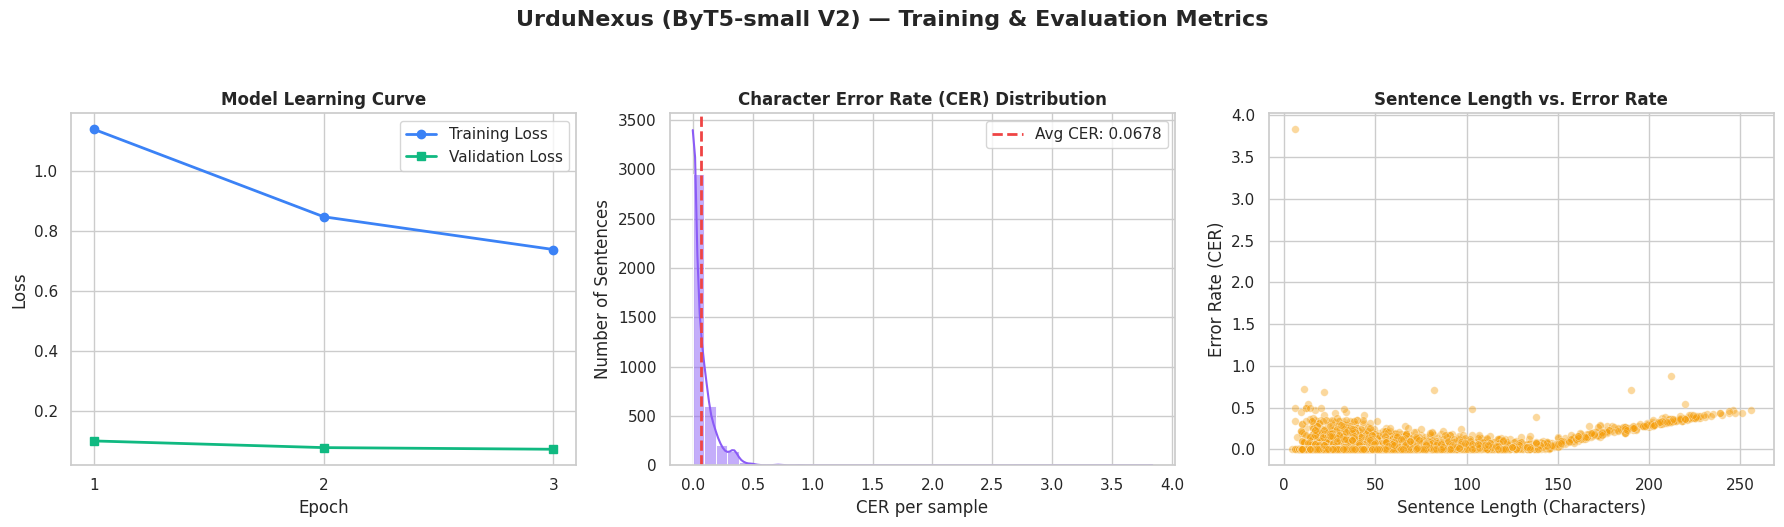

✅ High-resolution publication plots saved to: /content/drive/MyDrive/roman_urdu_byt5/results_v2/UrduNexus_Metrics_Final.png


In [ ]:
# CELL 19 — UPGRADED EVALUATION VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from jiwer import cer

# 1. Calculate CER on the fly if it doesn't exist
if 'CER' not in results_df.columns:
    print("Calculating CER for evaluation plots...")
    results_df['CER'] = results_df.apply(lambda row: cer(row['Ground_Truth_Urdu'], row['Predicted_Urdu']), axis=1)

# 2. Set modern aesthetic style
sns.set_theme(style="whitegrid", palette="muted")

# 3. Create a 1x3 grid for our plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("UrduNexus (ByT5-small V2) — Training & Evaluation Metrics", fontsize=16, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Plot 1: The Learning Curve (Loss vs Epochs)
# ---------------------------------------------------------
epochs = [1, 2, 3]
train_loss = [1.1372, 0.8459, 0.7368]
val_loss = [0.0991, 0.0769, 0.0714]

axes[0].plot(epochs, train_loss, label='Training Loss', marker='o', linewidth=2, color='#3b82f6')
axes[0].plot(epochs, val_loss, label='Validation Loss', marker='s', linewidth=2, color='#10b981')
axes[0].set_title("Model Learning Curve", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(epochs)
axes[0].legend()

# ---------------------------------------------------------
# Plot 2: CER Histogram
# ---------------------------------------------------------
sns.histplot(data=results_df, x='CER', bins=40, kde=True, ax=axes[1], color='#8b5cf6')
axes[1].set_title("Character Error Rate (CER) Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("CER per sample")
axes[1].set_ylabel("Number of Sentences")
mean_cer = results_df['CER'].mean()
axes[1].axvline(mean_cer, color='#ef4444', linestyle='--', linewidth=2,
                label=f"Avg CER: {mean_cer:.4f}")
axes[1].legend()

# ---------------------------------------------------------
# Plot 3: Length vs. Error Scatter
# ---------------------------------------------------------
sns.scatterplot(data=results_df, x=results_df['Ground_Truth_Urdu'].str.len(),
                y='CER', alpha=0.4, s=30, ax=axes[2], color='#f59e0b')
axes[2].set_title("Sentence Length vs. Error Rate", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Sentence Length (Characters)")
axes[2].set_ylabel("Error Rate (CER)")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/UrduNexus_Metrics_Final.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ High-resolution publication plots saved to: {RESULTS_DIR}/UrduNexus_Metrics_Final.png")

## 🔤 Phase 8 — Standalone Transliteration Engine

In [ ]:
# CELL 20 — MODEL LOADING ONLY (CLEAN SETUP)
# ─────────────────────────────────────────────

from google.colab import drive
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("--- MOUNTING GOOGLE DRIVE ---")
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/roman_urdu_byt5/final_model_v2"

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\nHardware: {device.upper()}")
print(f"Loading model from: {MODEL_PATH}")

# Load tokenizer + model
inf_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
inf_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH).to(device)
inf_model.eval()

# IMPORTANT: keep consistent with training
MAX_LENGTH = 256
inf_tokenizer.model_max_length = MAX_LENGTH

print("✅ Model loaded successfully!")

--- MOUNTING GOOGLE DRIVE ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Hardware: CUDA
Loading model from: /content/drive/MyDrive/roman_urdu_byt5/final_model_v2


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✅ Model loaded successfully!


In [ ]:
# CELL 21 — NO-TRUNCATION PRODUCTION ENGINE
# ─────────────────────────────────────────────

import re
import torch


# -----------------------------
# 1. SMART TEXT SPLITTER
# -----------------------------
def split_roman_urdu(text: str):
    """
    Splits long Roman Urdu into safe chunks.
    Prevents truncation completely.
    """
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # sentence split
    sentences = re.split(r'(?<=[.!?])\s+', text)

    chunks = []

    for s in sentences:
        if len(s) <= 200:
            chunks.append(s)
        else:
            words = s.split()
            temp = []
            length = 0

            for w in words:
                temp.append(w)
                length += len(w)

                if length > 180:
                    chunks.append(" ".join(temp))
                    temp = []
                    length = 0

            if temp:
                chunks.append(" ".join(temp))

    return [c for c in chunks if c.strip()]


# -----------------------------
# 2. TRANSLITERATION CORE
# -----------------------------
def transliterate_chunk(text: str) -> str:
    inputs = inf_tokenizer(
        text.lower().strip(),
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = inf_model.generate(
            **inputs,
            max_new_tokens=256,
            num_beams=4,
            do_sample=False
        )

    return inf_tokenizer.decode(outputs[0], skip_special_tokens=True)


# -----------------------------
# 3. FULL PARAGRAPH ENGINE
# -----------------------------
def transliterate_production(text: str) -> str:
    if not text.strip():
        return ""

    chunks = split_roman_urdu(text)

    results = []
    for chunk in chunks:
        results.append(transliterate_chunk(chunk))

    return " ".join(results).strip()

In [ ]:
# CELL 22 — INTERACTIVE TRANSLITERATION ENGINE
# ─────────────────────────────────────────────

print("=" * 60)
print("🚀 NO-TRUNCATION ROMAN URDU → URDU ENGINE")
print("Type 'exit' or 'quit' to stop")
print("=" * 60)

while True:
    user_input = input("\nRoman Urdu : ")

    if user_input.lower().strip() in ("exit", "quit"):
        print("\nKhuda Hafiz 👋")
        break

    output = transliterate_production(user_input)

    print(f"\nUrdu Script: {output}")
    print("-" * 60)

🚀 NO-TRUNCATION ROMAN URDU → URDU ENGINE
Type 'exit' or 'quit' to stop

Roman Urdu : acha

Urdu Script: اچھا
------------------------------------------------------------

Roman Urdu : achha

Urdu Script: اچھا
------------------------------------------------------------

Roman Urdu : achaa

Urdu Script: اچھا
------------------------------------------------------------

Roman Urdu : bht aala kaam ho raha hai laikin mai bht thak gayi hun

Urdu Script: بھت آلا کام ہو رہا ہے لیکن میں بھت تھک گئی ہوں
------------------------------------------------------------

Roman Urdu : bohat aalaa kaam ho raha laikin kia hi kar sakti hun

Urdu Script: بہت آلا کام ہو رہا لیکن کیا ہی کر سکتی ہوں
------------------------------------------------------------

Roman Urdu : aur sunao kia haal hai tumhara suna hai tumhara nateeja bohat acha aya is sai tumhari qabliyat sabit hoti hai

Urdu Script: اور سناؤ کیا حال ہے تمہارا سنا ہے تمہارا نتیجہ بہت اچھا آیا اس سے تمہاری قابلیت ثابت ہوتی ہے
-----------------------